In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/RailGuard/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/RailGuard/models', exist_ok=True)
print("Folders created")

Folders created


In [ ]:
!pip install ultralytics opencv-python-headless -q

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
base = '/content/drive/MyDrive/RailGuard/data'
print("Base exists:", os.path.exists(base))
print("Base contents:", os.listdir(base))

Base exists: True
Base contents: ['archive']


In [ ]:
import os
path = '/content/drive/MyDrive/RailGuard/data/archive'
for root, dirs, filenames in os.walk(path):
    print(root, '->', len(filenames), 'files')

/content/drive/MyDrive/RailGuard/data/archive -> 0 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated -> 0 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Test -> 0 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Test/Non defective -> 11 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Test/Defective -> 11 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Train -> 0 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Train/Defective -> 150 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Train/Non defective -> 150 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/Validation -> 0 files
/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated/V

In [ ]:
import os

base = '/content/drive/MyDrive/RailGuard/data/archive/Railway Track fault Detection Updated'

train_defective = os.path.join(base, 'Train', 'Defective')
train_nondefective = os.path.join(base, 'Train', 'Non defective')
val_defective = os.path.join(base, 'Validation', 'Defective')
val_nondefective = os.path.join(base, 'Validation', 'Non defective')
test_defective = os.path.join(base, 'Test', 'Defective')
test_nondefective = os.path.join(base, 'Test', 'Non defective')

print("Train defective:", len(os.listdir(train_defective)))
print("Train non-defective:", len(os.listdir(train_nondefective)))

Train defective: 150
Train non-defective: 150


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_dir = os.path.join(base, 'Train')
val_dir = os.path.join(base, 'Validation')
test_dir = os.path.join(base, 'Test')

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
val_gen = val_test_datagen.flow_from_directory(
    val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)
test_gen = val_test_datagen.flow_from_directory(
    test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

print(train_gen.class_indices)

Found 299 images belonging to 2 classes.
Found 62 images belonging to 2 classes.
Found 22 images belonging to 2 classes.
{'Defective': 0, 'Non defective': 1}


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False  # freeze pretrained layers first

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)  # binary output

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15
)

Epoch 1/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 423s 21s/step - accuracy: 0.5920 - loss: 0.7231 - val_accuracy: 0.6935 - val_loss: 0.5587
Epoch 2/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.7559 - loss: 0.5147 - val_accuracy: 0.6935 - val_loss: 0.5140
Epoch 3/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8161 - loss: 0.3859 - val_accuracy: 0.7903 - val_loss: 0.4442
Epoch 4/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 50s 3s/step - accuracy: 0.8227 - loss: 0.3926 - val_accuracy: 0.6290 - val_loss: 0.6108
Epoch 5/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8595 - loss: 0.3386 - val_accuracy: 0.7097 - val_loss: 0.5542
Epoch 6/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.8328 - loss: 0.3397 - val_accuracy: 0.8065 - val_loss: 0.4730
Epoch 7/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - accuracy: 0.8829 - loss: 0.2696 - val_accuracy: 0.7419 - val_loss: 0.5350
Epoch 8/15
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8829 - loss: 0.2495 - val_accuracy: 0.7581 - val_los

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

In [ ]:
train_gen = train_datagen.flow_from_directory(
    train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='binary'
)

Found 299 images belonging to 2 classes.


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/drive/MyDrive/RailGuard/models/best_cnn_model.keras',
    monitor='val_accuracy',
    save_best_only=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 77s 4s/step - accuracy: 0.6722 - loss: 0.6322 - val_accuracy: 0.7097 - val_loss: 0.5871
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.7492 - loss: 0.5011 - val_accuracy: 0.7581 - val_loss: 0.5453
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 57s 3s/step - accuracy: 0.7860 - loss: 0.4706 - val_accuracy: 0.7903 - val_loss: 0.4904
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.8194 - loss: 0.4044 - val_accuracy: 0.7419 - val_loss: 0.5086
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 53s 3s/step - accuracy: 0.8027 - loss: 0.4167 - val_accuracy: 0.7581 - val_loss: 0.5289
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 51s 3s/step - accuracy: 0.8395 - loss: 0.3456 - val_accuracy: 0.7581 - val_loss: 0.4991
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8328 - loss: 0.3627 - val_accuracy: 0.7258 - val_loss: 0.5889
Epoch 8/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.8562 - loss: 0.3177 - val_accuracy: 0.7097 - val_loss:

In [ ]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 811ms/step - accuracy: 0.8182 - loss: 0.3955
Test Accuracy: 81.82%
Test Loss: 0.3955


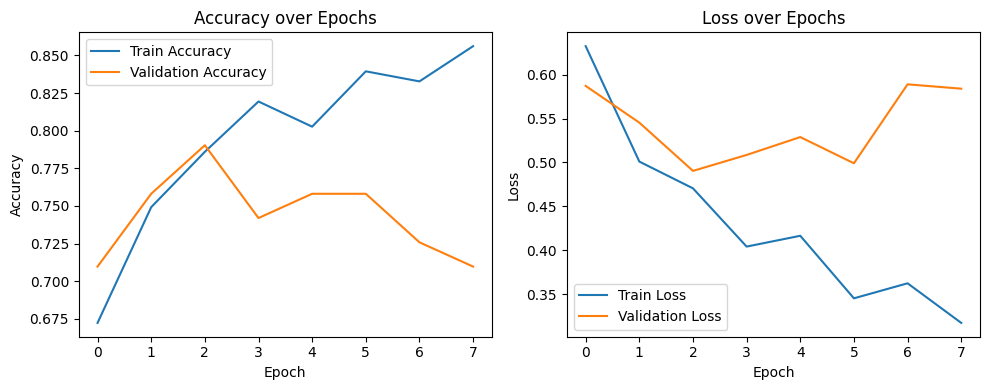

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/RailGuard/models/cnn_training_curves.png')
plt.show()

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

AE_IMG_SIZE = (128, 128)  # smaller size keeps autoencoder fast to train
AE_BATCH_SIZE = 16

# Only rescale — no augmentation needed for reconstruction-based training
ae_datagen = ImageDataGenerator(rescale=1./255)

# We'll point flow_from_directory at the parent folder but only include Non defective
# Easiest way: use flow_from_directory with classes=['Non defective'] and class_mode=None
ae_train_gen = ae_datagen.flow_from_directory(
    train_dir,
    target_size=AE_IMG_SIZE,
    batch_size=AE_BATCH_SIZE,
    classes=['Non defective'],
    class_mode='input',   # input mode: target = input image itself (for reconstruction)
    shuffle=True
)

ae_val_gen = ae_datagen.flow_from_directory(
    val_dir,
    target_size=AE_IMG_SIZE,
    batch_size=AE_BATCH_SIZE,
    classes=['Non defective'],
    class_mode='input',
    shuffle=False
)

print("AE train samples:", ae_train_gen.samples)
print("AE val samples:", ae_val_gen.samples)

Found 150 images belonging to 1 classes.
Found 31 images belonging to 1 classes.
AE train samples: 150
AE val samples: 31


In [ ]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(128, 128, 3))

# Encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = Conv2D(16, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)
x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)
decoded = Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 3)    │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,347 (52.14 KB)

 Trainable params: 13,347 (52.14 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_ae = autoencoder.fit(
    ae_train_gen,
    validation_data=ae_val_gen,
    epochs=30
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - loss: 0.0420 - val_loss: 0.0461
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - loss: 0.0348 - val_loss: 0.0330
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 0.0256 - val_loss: 0.0246
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - loss: 0.0201 - val_loss: 0.0219
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 0.0178 - val_loss: 0.0203
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - loss: 0.0170 - val_loss: 0.0195
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - loss: 0.0164 - val_loss: 0.0188
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 33s 3s/step - loss: 0.0157 - val_loss: 0.0181
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - loss: 0.0152 - val_loss: 0.0176
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 28s 3s/step - loss: 0.0150 - val_loss: 0.0174
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 26s 3s/step - loss: 0.0145 - val_loss: 0.0166
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 3s/step - loss: 0.0140 - val_lo

In [ ]:
import numpy as np

# Get reconstruction errors on healthy validation images
val_images = []
ae_val_gen.reset()
for i in range(len(ae_val_gen)):
    batch = next(ae_val_gen)
    val_images.append(batch[0])
val_images = np.concatenate(val_images, axis=0)

reconstructions = autoencoder.predict(val_images)
mse = np.mean(np.square(val_images - reconstructions), axis=(1,2,3))

print("Reconstruction error stats on healthy images:")
print("Mean:", mse.mean())
print("Std:", mse.std())
print("Max:", mse.max())

# Set threshold: mean + 2 standard deviations (common approach)
threshold = mse.mean() + 2 * mse.std()
print("Anomaly threshold:", threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Reconstruction error stats on healthy images:
Mean: 0.013395564
Std: 0.004426336
Max: 0.02676828
Anomaly threshold: 0.022248235


In [ ]:
defect_gen = ae_datagen.flow_from_directory(
    val_dir,
    target_size=AE_IMG_SIZE,
    batch_size=AE_BATCH_SIZE,
    classes=['Defective'],
    class_mode='input',
    shuffle=False
)

defect_images = []
defect_gen.reset()
for i in range(len(defect_gen)):
    batch = next(defect_gen)
    defect_images.append(batch[0])
defect_images = np.concatenate(defect_images, axis=0)

defect_recon = autoencoder.predict(defect_images)
defect_mse = np.mean(np.square(defect_images - defect_recon), axis=(1,2,3))

print("Reconstruction error stats on DEFECTIVE images:")
print("Mean:", defect_mse.mean())
print("Std:", defect_mse.std())

flagged = np.sum(defect_mse > threshold)
print(f"Flagged as anomaly: {flagged} / {len(defect_mse)}")

Found 31 images belonging to 1 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
Reconstruction error stats on DEFECTIVE images:
Mean: 0.018357525
Std: 0.009684989
Flagged as anomaly: 8 / 31


In [ ]:
threshold = mse.mean() + 1 * mse.std()  # more sensitive
print("New threshold:", threshold)
flagged = np.sum(defect_mse > threshold)
print(f"Flagged as anomaly: {flagged} / {len(defect_mse)}")

New threshold: 0.0178219
Flagged as anomaly: 13 / 31


In [ ]:
for k in [0.5, 1, 1.5, 2]:
    t = mse.mean() + k * mse.std()
    healthy_fp = np.sum(mse > t)
    defect_tp = np.sum(defect_mse > t)
    print(f"k={k}: threshold={t:.4f} | Healthy false positives: {healthy_fp}/31 | Defective caught: {defect_tp}/31")

k=0.5: threshold=0.0156 | Healthy false positives: 7/31 | Defective caught: 16/31
k=1: threshold=0.0178 | Healthy false positives: 3/31 | Defective caught: 13/31
k=1.5: threshold=0.0200 | Healthy false positives: 2/31 | Defective caught: 10/31
k=2: threshold=0.0222 | Healthy false positives: 2/31 | Defective caught: 8/31


In [ ]:
FINAL_THRESHOLD = mse.mean() + 1.0 * mse.std()
print("Final anomaly threshold:", FINAL_THRESHOLD)

Final anomaly threshold: 0.0178219


In [ ]:
autoencoder.save('/content/drive/MyDrive/RailGuard/models/autoencoder.keras')

import json
with open('/content/drive/MyDrive/RailGuard/models/ae_threshold.json', 'w') as f:
    json.dump({'threshold': float(FINAL_THRESHOLD)}, f)

print("Autoencoder and threshold saved.")

Autoencoder and threshold saved.


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="tFyDnuTmLMcuyMnv61Ky")
project = rf.workspace("rail-defect").project("rail-track-defect")
version = project.version(2)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.3/260.3 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 89.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 146.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
httpx2 2.4.0 requires idna>=3.18, but you have idna 3.7 which i


Extracting Dataset Version Zip to Rail-track-defect-2 in yolov8:: 100%|██████████| 28/28 [00:00<00:00, 5012.40it/s]


In [ ]:
import os
print(os.listdir(dataset.location))
print(os.listdir(dataset.location + '/train/images')[:5])

with open(dataset.location + '/data.yaml') as f:
    print(f.read())

['valid', 'README.dataset.txt', 'train', 'test', 'README.roboflow.txt', 'data.yaml']
['IMG_20201114_100315_jpg.rf.cc232702af901fa95f6169d62c8905af.jpg', 'IMG_20201114_100315_jpg.rf.6fd87470399798b6f0160df0922d0f8d.jpg', '6411009_jpg.rf.608b43f2baf86a97cc1099f8f1ab060d.jpg', 'IMG_20201114_100315_jpg.rf.9f145b2f2f87185896049133301863b1.jpg', '6411009_jpg.rf.0ce6da27e1fe04c60206646c01c8c0ab.jpg']
names:
- crack
nc: 1
roboflow:
  license: CC BY 4.0
  project: rail-track-defect
  url: https://universe.roboflow.com/rail-defect/rail-track-defect/dataset/2
  version: 2
  workspace: rail-defect
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
!pip install ultralytics -q
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=50,
    imgsz=640,
    project='/content/drive/MyDrive/RailGuard/models',
    name='yolo_defect_v1'
)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 65.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rail-track-defect-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynam

In [ ]:
import os
for split in ['train', 'valid', 'test']:
    img_dir = f'{dataset.location}/{split}/images'
    print(split, ':', len(os.listdir(img_dir)), 'images')

train : 6 images
valid : 1 images
test : 1 images


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="tFyDnuTmLMcuyMnv61Ky")
project = rf.workspace("rail-defect").project("rail-track-defect")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Rail-track-defect-1 in yolov8:: 100%|██████████| 107/107 [00:00<00:00, 6689.68it/s]


In [ ]:
import os
for split in ['train', 'valid', 'test']:
    img_dir = f'{dataset.location}/{split}/images'
    print(split, ':', len(os.listdir(img_dir)), 'images')

with open(dataset.location + '/data.yaml') as f:
    print(f.read())

train : 36 images
valid : 10 images
test : 5 images
names:
- crack
- expand
- no defect
- weak
- wear-tear
nc: 5
roboflow:
  license: CC BY 4.0
  project: rail-track-defect
  url: https://universe.roboflow.com/rail-defect/rail-track-defect/dataset/1
  version: 1
  workspace: rail-defect
test: ../test/images
train: ../train/images
val: ../valid/images



In [ ]:
!pip install ultralytics -q

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.train(
    data=f'{dataset.location}/data.yaml',
    epochs=50,
    imgsz=640,
    project='/content/drive/MyDrive/RailGuard/models',
    name='yolo_defect_v2'
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rail-track-defect-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_defect_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [ ]:
import glob

test_images = glob.glob(f'{dataset.location}/valid/images/*') + glob.glob(f'{dataset.location}/test/images/*')

best_model = YOLO('/content/drive/MyDrive/RailGuard/models/yolo_defect_v2/weights/best.pt')

for img_path in test_images:
    results = best_model(img_path, conf=0.25)
    boxes = results[0].boxes
    if len(boxes) > 0:
        print(f"{img_path.split('/')[-1]} -> {len(boxes)} detection(s)")


image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_101138_jpg.rf.a84087677a9f5a8c31198068c70d3085.jpg: 640x640 (no detections), 17.4ms
Speed: 4.8ms preprocess, 17.4ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_102712_jpg.rf.603eaeb710e81216ff3e1a49fe337b8f.jpg: 640x640 (no detections), 12.4ms
Speed: 2.1ms preprocess, 12.4ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_101801_jpg.rf.03a5e85d588323caac4fc3f567fab1fa.jpg: 640x640 (no detections), 13.0ms
Speed: 2.0ms preprocess, 13.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_102839_jpg.rf.cb24bc7fb7834436d2dddff8f6f8f735.jpg: 640x640 (no detections), 20.2ms
Speed: 3.8ms preprocess, 20.2ms inference, 2.8ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /

In [ ]:
import os
os.makedirs('/content/drive/MyDrive/RailGuard/models/demo_predictions', exist_ok=True)

for img_path in test_images:
    results = best_model(img_path, conf=0.25)
    if len(results[0].boxes) > 0:
        results[0].save(filename=f"/content/drive/MyDrive/RailGuard/models/demo_predictions/{img_path.split('/')[-1]}")

print("Saved demo predictions.")


image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_101138_jpg.rf.a84087677a9f5a8c31198068c70d3085.jpg: 640x640 (no detections), 8.9ms
Speed: 2.2ms preprocess, 8.9ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_102712_jpg.rf.603eaeb710e81216ff3e1a49fe337b8f.jpg: 640x640 (no detections), 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_101801_jpg.rf.03a5e85d588323caac4fc3f567fab1fa.jpg: 640x640 (no detections), 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/valid/images/IMG_20201114_102839_jpg.rf.cb24bc7fb7834436d2dddff8f6f8f735.jpg: 640x640 (no detections), 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/

In [ ]:
train_images = glob.glob(f'{dataset.location}/train/images/*')

os.makedirs('/content/drive/MyDrive/RailGuard/models/demo_predictions', exist_ok=True)

count = 0
for img_path in train_images:
    results = best_model(img_path, conf=0.25)
    if len(results[0].boxes) > 0:
        results[0].save(filename=f"/content/drive/MyDrive/RailGuard/models/demo_predictions/{img_path.split('/')[-1]}")
        print(f"{img_path.split('/')[-1]} -> {len(results[0].boxes)} detection(s)")
        count += 1

print(f"\nTotal demo images saved: {count}")


image 1/1 /content/Rail-track-defect-1/train/images/IMG_20201114_101537_jpg.rf.789b5a2d0bcfa2209a3fce3398d9b23b.jpg: 640x640 (no detections), 8.7ms
Speed: 2.3ms preprocess, 8.7ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/train/images/images-2-_jpeg.rf.2461156384ecaf8a24cb594133e1bee1.jpg: 640x640 (no detections), 7.2ms
Speed: 1.4ms preprocess, 7.2ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/train/images/IMG_20201114_102902_jpg.rf.5d6b0d189eec954b488f0f3ae9ed2421.jpg: 640x640 (no detections), 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/Rail-track-defect-1/train/images/IMG_20201114_100242_jpg.rf.6b0354943404ec42286aceb9b333369e.jpg: 640x640 3 no defects, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)
IMG_20201114_100242_jpg.rf.6b035

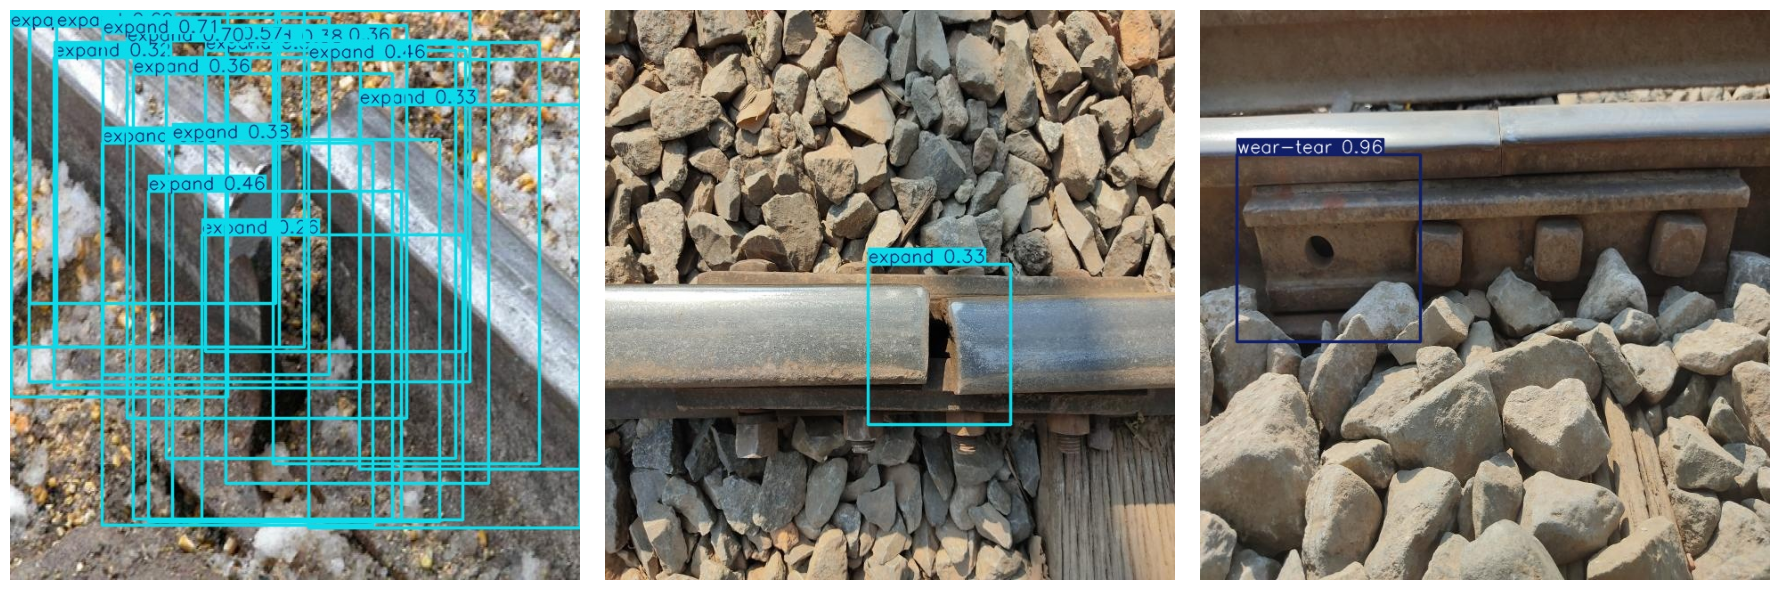

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

demo_dir = '/content/drive/MyDrive/RailGuard/models/demo_predictions'
sample_files = [
    'unnamed_jpg.rf.ca11500b2a31e3b75c1561b184f66337.jpg',
    'IMG_20201114_101121_jpg.rf.749871cf2d38b970d8cea3cec7d1dbb0.jpg',
    'IMG_20201114_102058_jpg.rf.64b6aa089da820925d94c4e2f164f917.jpg'
]

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, fname in zip(axes, sample_files):
    img = Image.open(f'{demo_dir}/{fname}')
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
import os
models_dir = '/content/drive/MyDrive/RailGuard/models'
print(os.listdir(models_dir))

['demo_predictions', 'yolo_defect_v2', 'yolo_defect_v1']


In [ ]:
!rm -rf /content/drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
models_dir = '/content/drive/MyDrive/RailGuard/models'
print(os.listdir(models_dir))

['best_cnn_model.keras', 'cnn_training_curves.png', 'autoencoder.keras', 'ae_threshold.json', 'yolo_defect_v1']


In [ ]:
import os
models_dir = '/content/drive/MyDrive/RailGuard/models'
for item in os.listdir(models_dir):
    print(item)

# Also check inside yolo_defect_v1 to see if v2 nested oddly
print("\nInside yolo_defect_v1:")
print(os.listdir(os.path.join(models_dir, 'yolo_defect_v1')))

best_cnn_model.keras
cnn_training_curves.png
autoencoder.keras
ae_threshold.json
yolo_defect_v1

Inside yolo_defect_v1:
['weights', 'args.yaml', 'labels.jpg', 'train_batch0.jpg', 'train_batch1.jpg', 'train_batch2.jpg', 'train_batch40.jpg', 'train_batch41.jpg', 'train_batch42.jpg', 'results.csv', 'val_batch0_pred.jpg', 'val_batch0_labels.jpg', 'BoxPR_curve.png', 'BoxF1_curve.png', 'BoxP_curve.png', 'BoxR_curve.png', 'confusion_matrix_normalized.png', 'confusion_matrix.png', 'results.png']


In [ ]:
print(os.listdir('/content'))

['.config', 'yolo26n.pt', 'Rail-track-defect-2', 'drive', 'Rail-track-defect-1', 'yolov8n.pt', 'sample_data']


In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
results = model.train(
    data='/content/Rail-track-defect-1/data.yaml',
    epochs=50,
    imgsz=640,
    project='/content/drive/MyDrive/RailGuard/models',
    name='yolo_defect_v2'
)

Ultralytics 8.4.84 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Rail-track-defect-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_defect_v2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/RailGuard/models'))
print(os.listdir('/content/drive/MyDrive/RailGuard/models/yolo_defect_v2/weights'))

['best_cnn_model.keras', 'cnn_training_curves.png', 'autoencoder.keras', 'ae_threshold.json', 'yolo_defect_v1', 'yolo_defect_v2']
['last.pt', 'best.pt']


In [ ]:
import numpy as np
import json
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.models import load_model
from ultralytics import YOLO

cnn_model = load_model('/content/drive/MyDrive/RailGuard/models/best_cnn_model.keras')
ae_model = load_model('/content/drive/MyDrive/RailGuard/models/autoencoder.keras')
yolo_model = YOLO('/content/drive/MyDrive/RailGuard/models/yolo_defect_v2/weights/best.pt')

with open('/content/drive/MyDrive/RailGuard/models/ae_threshold.json') as f:
    AE_THRESHOLD = json.load(f)['threshold']

print("All models loaded successfully.")
print("AE threshold:", AE_THRESHOLD)

All models loaded successfully.
AE threshold: 0.01782190054655075


In [ ]:
def analyze_image(img_path):
    result = {}

    # 1. YOLO detection
    yolo_results = yolo_model(img_path, conf=0.25, verbose=False)
    detections = []
    for box in yolo_results[0].boxes:
        detections.append({
            'class': yolo_model.names[int(box.cls)],
            'confidence': round(float(box.conf), 3)
        })
    result['yolo_detections'] = detections

    # 2. CNN classification
    img_cnn = keras_image.load_img(img_path, target_size=(224,224))
    arr_cnn = keras_image.img_to_array(img_cnn) / 255.0
    arr_cnn = np.expand_dims(arr_cnn, axis=0)
    cnn_pred = cnn_model.predict(arr_cnn, verbose=0)[0][0]
    result['cnn_classification'] = 'Non defective' if cnn_pred > 0.5 else 'Defective'
    result['cnn_confidence'] = round(float(cnn_pred if cnn_pred > 0.5 else 1 - cnn_pred), 3)

    # 3. Autoencoder anomaly check
    img_ae = keras_image.load_img(img_path, target_size=(128,128))
    arr_ae = keras_image.img_to_array(img_ae) / 255.0
    arr_ae_batch = np.expand_dims(arr_ae, axis=0)
    recon = ae_model.predict(arr_ae_batch, verbose=0)
    mse = np.mean(np.square(arr_ae_batch - recon))
    result['reconstruction_error'] = round(float(mse), 5)
    result['is_anomaly'] = bool(mse > AE_THRESHOLD)

    # 4. Recommendation logic
    if result['is_anomaly'] or result['cnn_classification'] == 'Defective':
        if result['cnn_confidence'] > 0.8 or result['is_anomaly']:
            result['recommendation'] = 'Immediate Repair'
        else:
            result['recommendation'] = 'Schedule Maintenance'
    else:
        result['recommendation'] = 'Continue Monitoring'

    return result

In [ ]:
def analyze_image(img_path):
    result = {}

    # 1. YOLO detection
    yolo_results = yolo_model(img_path, conf=0.25, verbose=False)
    detections = []
    for box in yolo_results[0].boxes:
        detections.append({
            'class': yolo_model.names[int(box.cls)],
            'confidence': round(float(box.conf), 3)
        })
    result['yolo_detections'] = detections

    # 2. CNN classification
    img_cnn = keras_image.load_img(img_path, target_size=(224,224))
    arr_cnn = keras_image.img_to_array(img_cnn) / 255.0
    arr_cnn = np.expand_dims(arr_cnn, axis=0)
    cnn_pred = cnn_model.predict(arr_cnn, verbose=0)[0][0]
    result['cnn_classification'] = 'Non defective' if cnn_pred > 0.5 else 'Defective'
    result['cnn_confidence'] = round(float(cnn_pred if cnn_pred > 0.5 else 1 - cnn_pred), 3)

    # 3. Autoencoder anomaly check
    img_ae = keras_image.load_img(img_path, target_size=(128,128))
    arr_ae = keras_image.img_to_array(img_ae) / 255.0
    arr_ae_batch = np.expand_dims(arr_ae, axis=0)
    recon = ae_model.predict(arr_ae_batch, verbose=0)
    mse = np.mean(np.square(arr_ae_batch - recon))
    result['reconstruction_error'] = round(float(mse), 5)
    result['is_anomaly'] = bool(mse > AE_THRESHOLD)

    # 4. Recommendation logic
    if result['is_anomaly'] or result['cnn_classification'] == 'Defective':
        if result['cnn_confidence'] > 0.8 or result['is_anomaly']:
            result['recommendation'] = 'Immediate Repair'
        else:
            result['recommendation'] = 'Schedule Maintenance'
    else:
        result['recommendation'] = 'Continue Monitoring'

    return result

In [ ]:
test_img = '/content/Rail-track-defect-1/train/images/unnamed_jpg.rf.ca11500b2a31e3b75c1561b184f66337.jpg'
result = analyze_image(test_img)
import pprint
pprint.pprint(result)

{'cnn_classification': 'Defective',
 'cnn_confidence': 0.991,
 'is_anomaly': False,
 'recommendation': 'Immediate Repair',
 'reconstruction_error': 0.0091,
 'yolo_detections': [{'class': 'expand', 'confidence': 0.712},
                     {'class': 'expand', 'confidence': 0.705},
                     {'class': 'expand', 'confidence': 0.685},
                     {'class': 'expand', 'confidence': 0.575},
                     {'class': 'expand', 'confidence': 0.459},
                     {'class': 'expand', 'confidence': 0.457},
                     {'class': 'expand', 'confidence': 0.419},
                     {'class': 'expand', 'confidence': 0.379},
                     {'class': 'expand', 'confidence': 0.379},
                     {'class': 'expand', 'confidence': 0.376},
                     {'class': 'expand', 'confidence': 0.359},
                     {'class': 'expand', 'confidence': 0.356},
                     {'class': 'expand', 'confidence': 0.332},
                     {'cl